# Around Heston model and calibration

We offer you the following practical task on the stochastic volatility models and how to put them to work.

Total score is **100**, which will be converted to $15\%$ of the course grade. You have $2$ weeks and a half for this work. **Hard deadline is the 15th of December, 23:59 MSK**.

The file must be submited to the platform.  Please rename your file as **"SurnameName_Lab2.ipynb"** before submission.

If you have any questions feel free to ask in Telegram in the **group chat**.

**Full name:** Петрова Елизавета Андреевна

**Faculty:** ВШЭ СПб "Прикладной анализ данных и искусственный интеллект"

## Episode 0: Preparations (0 points)

In [1]:
from typing import Union
from dataclasses import dataclass
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import pandas as pd
from py_vollib.black.implied_volatility import implied_volatility_of_undiscounted_option_price

implied_volatility_vec = np.vectorize(implied_volatility_of_undiscounted_option_price)

In [2]:
ZONE = ZoneInfo("Europe/Moscow")
ASSIGNMENT_DT = datetime(2025, 11, 28, 23, 10, 0, tzinfo=ZONE)
NO_PENALTY_PERIOD = timedelta(days=14)
HARD_DEADLINE = datetime(2025, 12, 15, 23, 59, 59, tzinfo=ZONE)
MAX_LAB_SCORE = 120

In [3]:
def get_score_multiplier(lab_hand_dt: datetime = datetime.now().astimezone()) -> float:
    """Calculate overeall lab score multiplier.

    The function calculates the lab score weighting factor, based on time,
    when the solved lab was handed in. The factor equals 1 during the
    `NO_PENALTY_PERIOD` starting at the `ASSIGNMENT_DT, then lineary decays
    towards 0 by the `HARD_DEADLINE`date.

    Args:
        lab_hand_dt: datetime when the lab is handed in. Now by default. Must be
        timezone-aware.

    Returns:
        A factor between 0 and 1, by which the final score will be multiplied.
    """
    assert lab_hand_dt.tzinfo is not None, \
        "The argument must be timezone-aware. Use `datetime.astimezone()` " \
        "to use your local timezone."

    if lab_hand_dt < ASSIGNMENT_DT + NO_PENALTY_PERIOD:
        return 1.

    decay_period = HARD_DEADLINE - ASSIGNMENT_DT - NO_PENALTY_PERIOD
    elapsed_with_penalty = lab_hand_dt - ASSIGNMENT_DT - NO_PENALTY_PERIOD
    factor = 1. - elapsed_with_penalty.total_seconds() / decay_period.total_seconds()
    return max(0., factor)

In [4]:
HAND_IN_DT = datetime.now().astimezone()
LAB_SCORE = 120
print(f"Final score is {int(LAB_SCORE * get_score_multiplier(HAND_IN_DT))}")

Final score is 120


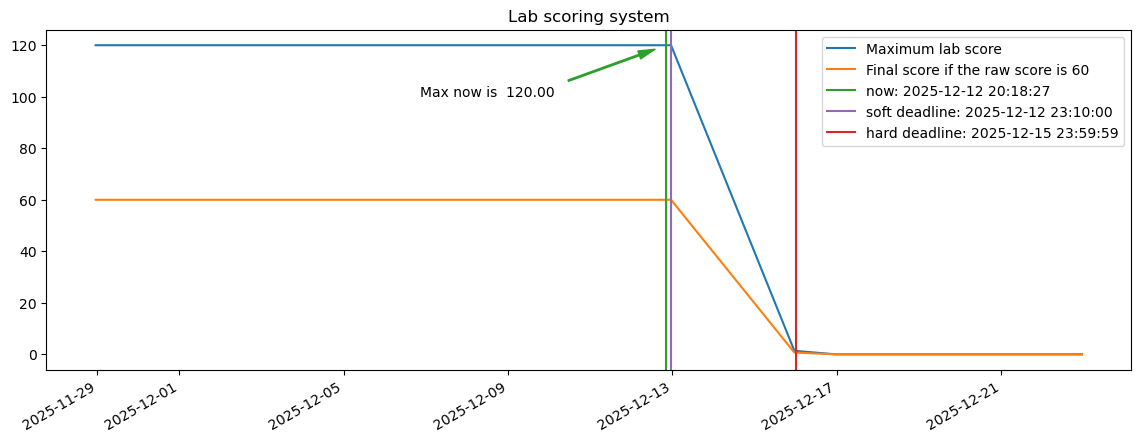

In [5]:
EXAMPLE_SCORE = 60

index = pd.date_range(ASSIGNMENT_DT, HARD_DEADLINE + timedelta(days=7))
mult = index.map(get_score_multiplier)
score = pd.DataFrame(
    index=index,
    data={
        "Maximum lab score": mult * MAX_LAB_SCORE,
        f"Final score if the raw score is {EXAMPLE_SCORE}": mult * EXAMPLE_SCORE,
    }
)

sd = ASSIGNMENT_DT + NO_PENALTY_PERIOD
hd = HARD_DEADLINE
now = datetime.now().astimezone()
score_now = get_score_multiplier(now) * MAX_LAB_SCORE

_, ax = plt.subplots(figsize=(14, 5))
score.plot(ax=ax)
ax.set_title("Lab scoring system")
ax.axvline(now, c="C2", label=f"now: {now:%F %T}")
ax.axvline(sd, c="C4", label=f"soft deadline: {sd:%F %T}")
ax.axvline(hd, c="C3", label=f"hard deadline: {hd:%F %T}")
ax.annotate(
    text=f"Max now is {score_now: .2f}",
    xy=(now, score_now),
    xytext=(now - timedelta(days=6), score_now - 20),
    arrowprops=dict(
        facecolor="C2", edgecolor="C2", shrink=0.1, width=1, headwidth=6
    ),
)
ax.legend()
plt.show()

## Episode 1: Around COS method (80 points)

Recall the COS method final formula providing the evaluation of the integral of the payoff function with respect to the underlying proce density

$$
C\approx DF(0, T)
\left(\frac{V_0}{2}
  + \sum_{n=1}^N \mathrm{Re}\left\{
    \phi_T\left(\frac{n\pi}{b-a}\right)e^{-in\pi \frac{x(K) - a}{b-a}}
  \right\} V_n
\right),
$$
where $x(K) = \log \left(S_0 / K\right),\ DF(0, T) = e^{-rT}$ and $V_n$ can be found analytically for some payoff functions (e.g. for vanilla calls and puts).

For more details see the lecture slides or seminar workbooks.

In [6]:
FloatArray = npt.NDArray[np.float64]
Floats = Union[float, FloatArray]


@dataclass
class MarketState:
    stock_price: Floats
    interest_rate: Floats
    time: Floats = 0


@dataclass
class HestonParams:
    v: float  # initial variance V_0
    kappa: float  # speed of mean-reversion
    theta: float  # long-term mean
    sigma: float  # vol of vol
    rho: float  # correlation between brownian motions


@dataclass
class StockOption:
    strike_price: Floats
    expiration_time: Floats  # in years
    is_call: Union[bool, npt.NDArray[np.bool_]] = None

    def __post_init__(self):
        assert self.is_call is not None

    def payoff(self, stock_price: Floats) -> Floats:
        call_payoff = np.maximum(0, stock_price - self.strike_price)
        put_payoff = np.maximum(0, self.strike_price - stock_price)
        return np.where(self.is_call, call_payoff, put_payoff)


class CallStockOption(StockOption):
    def __post_init__(self):
        self.is_call = True


class PutStockOption(StockOption):
    def __post_init__(self):
        self.is_call = False

In [7]:
def heston_log_char_func(omega: Floats,
                         dt: Floats,
                         p: HestonParams) -> Floats:
    """Computes the logarithm og the Heston characteristic function assuming the stock
    trades at 1 and no drift.

    To recover the CF if the stock trades at s multiply by the factor
    exp(i omega (log(s) + \mu dt)) the exponent of the result.

    Args:
        omega: frequency dual to the price domain
        dt: time to evaluate CF at
        p: model parameters

    Returns:
        float: log characteristic function value
    """
    D = np.sqrt(
        (p.kappa - 1j * p.rho * p.sigma * omega) ** 2
        + (omega ** 2 + 1j * omega) * p.sigma ** 2
    )
    F = p.kappa - 1j * p.rho * p.sigma * omega - D
    G = F / (F + 2 * D)
    df = np.exp(-D * dt)  # discount factor
    return (
            p.v / p.sigma ** 2 * (1 - df) / (1 - G * df) * F
            + p.kappa * p.theta / p.sigma ** 2 * (
                    dt * F - 2 * np.log((1 - G * df) / (1 - G))
            )
    )

In [8]:
def vanilla_put_cos_expansion_coeffs(a: Floats,
                                     b: Floats,
                                     k: int) -> Floats:
    """
    Computes the cosine expansion coefficients of the vanilla put option
    payoff.

    Args:
        a, b: integration bounds for the payoff function
        k: number of coefficients

    Returns:
        vector of coefficients
    """

    ks = np.arange(k)
    a, b = a[..., None], b[..., None]  # new axis for coefficients
    c, d = a, np.zeros_like(a)

    c_frac = ks * np.pi * (c - a) / (b - a)
    d_frac = ks * np.pi * (d - a) / (b - a)

    chi = 1 / (1 + (ks * np.pi / (b - a)) ** 2) * (
            np.cos(d_frac) * np.exp(d) - np.cos(c_frac) * np.exp(c)
            + ks * np.pi / (b - a) * (
                    np.sin(d_frac) * np.exp(d) - np.sin(c_frac) * np.exp(c)
            )
    )

    psi = (b - a) / ks[1:] / np.pi * (
            np.sin(d_frac[..., 1:]) - np.sin(c_frac[..., 1:])
    )
    psi = np.insert(psi, 0, np.squeeze(d - c, axis=-1), axis=-1)

    return 2 / (b - a) * (psi - chi)

### Task 1: Choose the truncation range (30 points)


[Fang and Oosterlee](https://www.semanticscholar.org/paper/A-Novel-Pricing-Method-for-European-Options-Based-Fang-Oosterlee/436dec6733e44780c83ef757ec326f12d60e25e1) in [1] proposed some rule of thumb based on cumulats to get an idea how to choose the finite range $[a, b]$ on which the integration in COS method should be provided:
$$
[a, b] := \left[ c_{1} - L \sqrt{ c_{2} },\quad c_{1} + L \sqrt{ c_{2} } \right] \quad \text{with}\ L = 12,
$$
$$
[a, b] := \left[ c_{1} - L \sqrt{ c_{2} + \sqrt{ c_{4} }},\quad c_{1} + L \sqrt{ c_{2} + \sqrt{ c_{4} } } \right] \quad \text{with}\ L = 10,
$$
$$
[a, b] := \left[ c_{1} - L \sqrt{ c_{2} + \sqrt{ c_{4} + \sqrt{ c_{6} } }},\quad c_{1} + L \sqrt{ c_{2} + \sqrt{ c_{4} + \sqrt{ c_{6} } } } \right] \quad \text{with}\ L = 10.
$$
where $c_i$ is an $i$-th cumulant of the $x(K)$.

[Junike and Pankrashkin](https://www.sciencedirect.com/science/article/pii/S0096300322000212) in [2] provided an alternative method of choosing $[a, b]$ based on a
Markov's inequalities, which guarantees the convergence of COS method inside the interval:

$$
[a, b] :=  [-L + \mathbb{E} \log S_T,  \quad L + \mathbb{E} \log S_T],
\qquad L = \sqrt[n]{\frac{2 \mu_n K}{\varepsilon}},
$$

where $\mu_n$ is a log-price's $n$-th moment.

For more details on each of algorithm see the corresponding papers.

Your task is to implement and test an algorithm determining the truncation range $[a, b]$:

* Use any algorithm from the above you like most.

* The Heston parameters are the following $v=0.1, \kappa=2, \theta=0.1, \sigma=0.7, \rho=-0.2$.

* Let the spot price $S_0 = 100$ and interest rate $r = 5\%$.

* Show how your algorithm performs (in comparison with the standard approach) for short-maturity options. Plot a graphs of prices of call and puts for various maturities $[7d, 1m, 2m, 3m]$ (see the cell below for details) as functions of strikes.

In [9]:
strikes = np.linspace(40, 200, 50)
times = np.array([7 / 365, 30 / 365, 60 / 365, 90 / 365])

calls = CallStockOption(strike_price=strikes[None],
                        expiration_time=times[:, None])
puts = PutStockOption(strike_price=strikes[None],
                      expiration_time=times[:, None])

ms = MarketState(stock_price=100, interest_rate=0.05)

params = HestonParams(v=0.1, kappa=2, theta=0.1, sigma=0.7, rho=-0.2)

In [10]:
def calc_trunc_range(params: HestonParams, dt: float):
    """
    Cumulant-based truncation half-width for COS.

    We compute cumulants c2 and c4 of log S_T (for S0=1) from derivatives of
    log characteristic function at omega=0, then use Fang-Oosterlee rule:

        [a,b] = [c1 - L * sqrt(c2 + sqrt(c4)),  c1 + L * sqrt(c2 + sqrt(c4))]
        with L = 10

    In the provided pricing routine the interval is centered at mean_log_s_t = rT,
    so we return only the half-width:
        trunc_range = L * sqrt(c2 + sqrt(c4))
    """
    dt = np.asarray(dt)

    # finite-difference step for derivatives around omega=0
    h = 1e-4

    # sample points for 5-point central differences
    w_m2 = -2.0 * h
    w_m1 = -1.0 * h
    w_0 = 0.0
    w_p1 = 1.0 * h
    w_p2 = 2.0 * h

    # evaluate log CF at those points (broadcast-friendly)
    Lm2 = heston_log_char_func(w_m2, dt, params)
    Lm1 = heston_log_char_func(w_m1, dt, params)
    L0 = heston_log_char_func(w_0, dt, params)
    Lp1 = heston_log_char_func(w_p1, dt, params)
    Lp2 = heston_log_char_func(w_p2, dt, params)

    # 5-point central differences:
    # f''(0)  ≈ (-f(-2h) + 16 f(-h) - 30 f(0) + 16 f(h) - f(2h)) / (12 h^2)
    d2 = (-Lm2 + 16 * Lm1 - 30 * L0 + 16 * Lp1 - Lp2) / (12.0 * h ** 2)

    # f''''(0) ≈ (f(-2h) - 4 f(-h) + 6 f(0) - 4 f(h) + f(2h)) / h^4
    d4 = (Lm2 - 4 * Lm1 + 6 * L0 - 4 * Lp1 + Lp2) / (h ** 4)

    # cumulants: d^n/dw^n log φ(w)|0 = i^n c_n  =>  c_n = (1 / i^n) * derivative
    c2 = np.real(d2 / (1j ** 2))  # 1j**2 = -1
    c4 = np.real(d4 / (1j ** 4))  # 1j**4 = 1

    # numerical safety
    c2 = np.maximum(c2, 0.0)
    c4 = np.maximum(c4, 0.0)

    L = 10.0
    trunc_range = L * np.sqrt(c2 + np.sqrt(c4))
    trunc_range_min = 1e-3  # try 1e-3; if still warnings, use 1e-2
    trunc_range = np.maximum(trunc_range, trunc_range_min)

    return trunc_range

In [11]:
def price(
        option: StockOption,
        ms: MarketState,
        params: HestonParams,
        n_points: int = 4096,
):
    """
    Computes the prices of a gien options.

    Args:
        option: option's specifications (strikes, maturities, etc.)
        ms: market state (asset price, interest rate, etc.)
        params: parameters of Heston model.
        n_points: number of terms in Fourier expansion.
    """
    dt = np.asarray(option.expiration_time - ms.time)
    mean_log_s_t = ms.interest_rate * dt
    trunc_range = calc_trunc_range(params, dt)

    x = np.log(ms.stock_price / option.strike_price)
    trunc_lb = mean_log_s_t - trunc_range
    trunc_ub = mean_log_s_t + trunc_range
    x_within_bounds = ((x >= trunc_lb) & (x <= trunc_ub))

    # COS method
    cos_cf = vanilla_put_cos_expansion_coeffs(trunc_lb, trunc_ub, n_points)
    omega = (np.pi / (trunc_ub - trunc_lb))[..., None] * np.arange(n_points)

    df = np.exp(-ms.interest_rate * dt)  # discount factor
    lcf = (
            heston_log_char_func(omega, dt[..., None], params)
            + 1j * (x + mean_log_s_t - trunc_lb)[..., None] * omega
    )
    prod = np.exp(lcf) * cos_cf
    prod[..., 0] /= 2

    put_price = option.strike_price * df * np.real(prod.sum(-1))
    put_price_lb = np.maximum(option.strike_price * df - ms.stock_price, 0.0)

    call_price = put_price + ms.stock_price - option.strike_price * df
    call_price_lb = np.maximum(ms.stock_price - option.strike_price * df, 0.0)

    raw_price = np.where(option.is_call, call_price, put_price)
    price_lb = np.where(option.is_call, call_price_lb, put_price_lb)

    # ensure price fits the lower bound
    return np.maximum(
        np.where(x_within_bounds, raw_price, price_lb),
        price_lb,
    )

In [12]:
call_price = price(calls, ms, params)
put_price = price(puts, ms, params)

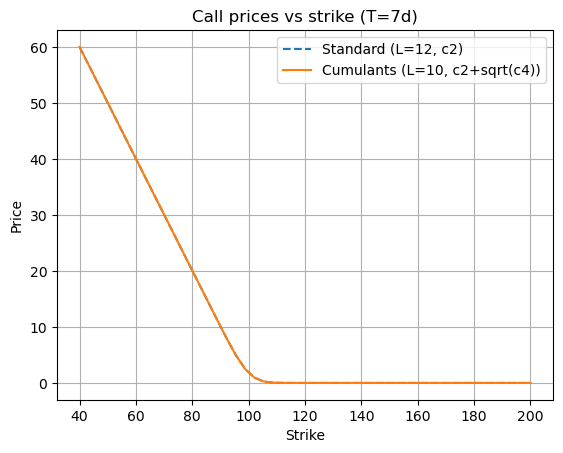

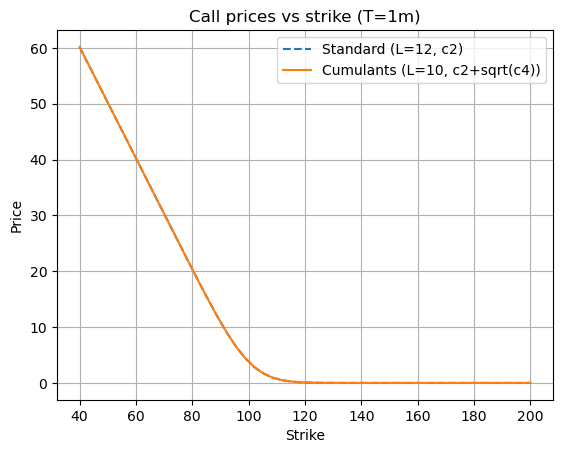

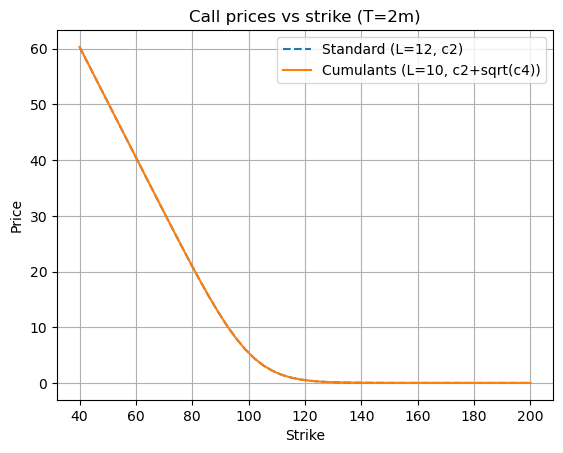

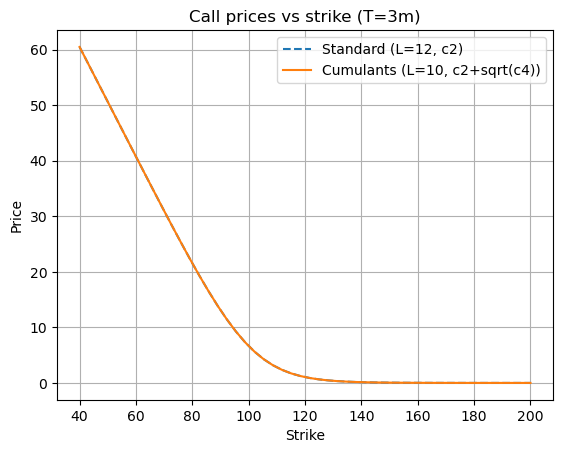

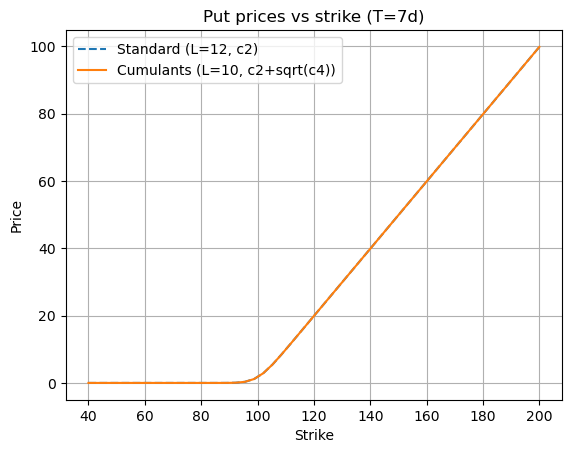

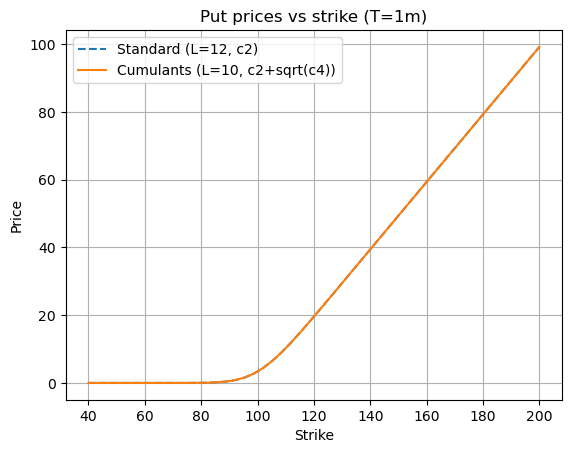

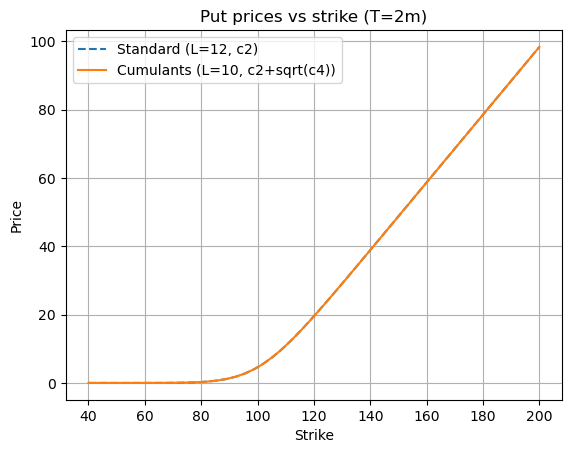

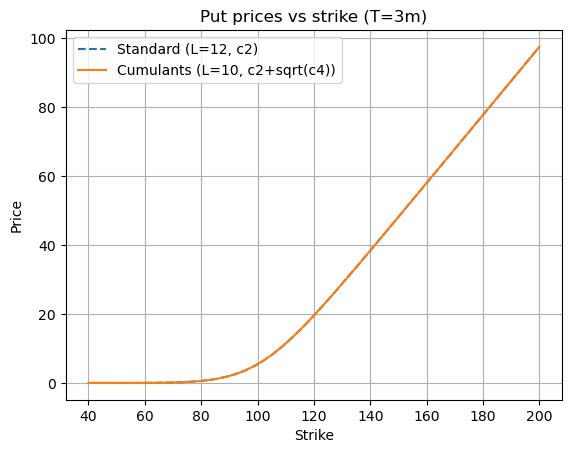

In [13]:
# Comparison vs standard truncation rule (c2-only) and plots

def calc_trunc_range_standard(params: HestonParams, dt: float):
    """
    Standard rule-of-thumb (often used as baseline):
        width = L * sqrt(c2), with L = 12
    where c2 is computed from log CF derivatives.
    """
    dt = np.asarray(dt)
    h = 1e-4

    w_m2 = -2.0 * h
    w_m1 = -1.0 * h
    w_0 = 0.0
    w_p1 = 1.0 * h
    w_p2 = 2.0 * h

    Lm2 = heston_log_char_func(w_m2, dt, params)
    Lm1 = heston_log_char_func(w_m1, dt, params)
    L0 = heston_log_char_func(w_0, dt, params)
    Lp1 = heston_log_char_func(w_p1, dt, params)
    Lp2 = heston_log_char_func(w_p2, dt, params)

    d2 = (-Lm2 + 16 * Lm1 - 30 * L0 + 16 * Lp1 - Lp2) / (12.0 * h ** 2)
    c2 = np.real(d2 / (1j ** 2))
    c2 = np.maximum(c2, 0.0)

    L = 12.0
    return L * np.sqrt(c2)


def price_with_trunc_func(
        option: StockOption,
        ms: MarketState,
        params: HestonParams,
        trunc_func,
        n_points: int = 4096,
):
    dt = np.asarray(option.expiration_time - ms.time)
    mean_log_s_t = ms.interest_rate * dt
    trunc_range = trunc_func(params, dt)

    x = np.log(ms.stock_price / option.strike_price)
    trunc_lb = mean_log_s_t - trunc_range
    trunc_ub = mean_log_s_t + trunc_range
    x_within_bounds = ((x >= trunc_lb) & (x <= trunc_ub))

    cos_cf = vanilla_put_cos_expansion_coeffs(trunc_lb, trunc_ub, n_points)
    omega = (np.pi / (trunc_ub - trunc_lb))[..., None] * np.arange(n_points)

    df = np.exp(-ms.interest_rate * dt)
    lcf = (
            heston_log_char_func(omega, dt[..., None], params)
            + 1j * (x + mean_log_s_t - trunc_lb)[..., None] * omega
    )
    prod = np.exp(lcf) * cos_cf
    prod[..., 0] /= 2

    put_price = option.strike_price * df * np.real(prod.sum(-1))
    put_price_lb = np.maximum(option.strike_price * df - ms.stock_price, 0.0)

    call_price = put_price + ms.stock_price - option.strike_price * df
    call_price_lb = np.maximum(ms.stock_price - option.strike_price * df, 0.0)

    raw_price = np.where(option.is_call, call_price, put_price)
    price_lb = np.where(option.is_call, call_price_lb, put_price_lb)

    return np.maximum(
        np.where(x_within_bounds, raw_price, price_lb),
        price_lb,
    )


call_price_new = price_with_trunc_func(calls, ms, params, calc_trunc_range)
put_price_new = price_with_trunc_func(puts, ms, params, calc_trunc_range)

call_price_std = price_with_trunc_func(calls, ms, params, calc_trunc_range_standard)
put_price_std = price_with_trunc_func(puts, ms, params, calc_trunc_range_standard)

# Plots: for each maturity, price vs strike for calls and puts
import matplotlib.pyplot as plt

maturity_labels = [
    "7d",
    "1m",
    "2m",
    "3m",
]

# Calls
for i, lab in enumerate(maturity_labels):
    plt.figure()
    plt.plot(strikes, call_price_std[i], label="Standard (L=12, c2)", linestyle="--", color='tab:blue')
    plt.plot(strikes, call_price_new[i], label="Cumulants (L=10, c2+sqrt(c4))", linestyle="-", color='tab:orange')
    plt.title(f"Call prices vs strike (T={lab})")
    plt.xlabel("Strike")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)

# Puts
for i, lab in enumerate(maturity_labels):
    plt.figure()
    plt.plot(strikes, put_price_std[i], label="Standard (L=12, c2)", linestyle='--', color='tab:blue')
    plt.plot(strikes, put_price_new[i], label="Cumulants (L=10, c2+sqrt(c4))", linestyle='-', color='tab:orange')
    plt.title(f"Put prices vs strike (T={lab})")
    plt.xlabel("Strike")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)

plt.show()

Plots are over each other, lets make sure that everything is correct

In [14]:
print("max |call_new - call_std| per maturity:",
      np.max(np.abs(call_price_new - call_price_std), axis=1))
print("max |put_new - put_std| per maturity:",
      np.max(np.abs(put_price_new - put_price_std), axis=1))

max |call_new - call_std| per maturity: [9.85756955e-07 3.81914998e-05 1.58539135e-04 3.28984377e-04]
max |put_new - put_std| per maturity: [9.85756952e-07 3.81914998e-05 1.58539136e-04 3.28984377e-04]


In [15]:
dt = times
print("standard trunc_range:", calc_trunc_range_standard(params, dt))
print("new trunc_range     :", calc_trunc_range(params, dt))

standard trunc_range: [0.52586126 1.09100662 1.5471453  1.8997925 ]
new trunc_range     : [0.43821772 0.90917219 1.28928775 1.58316042]


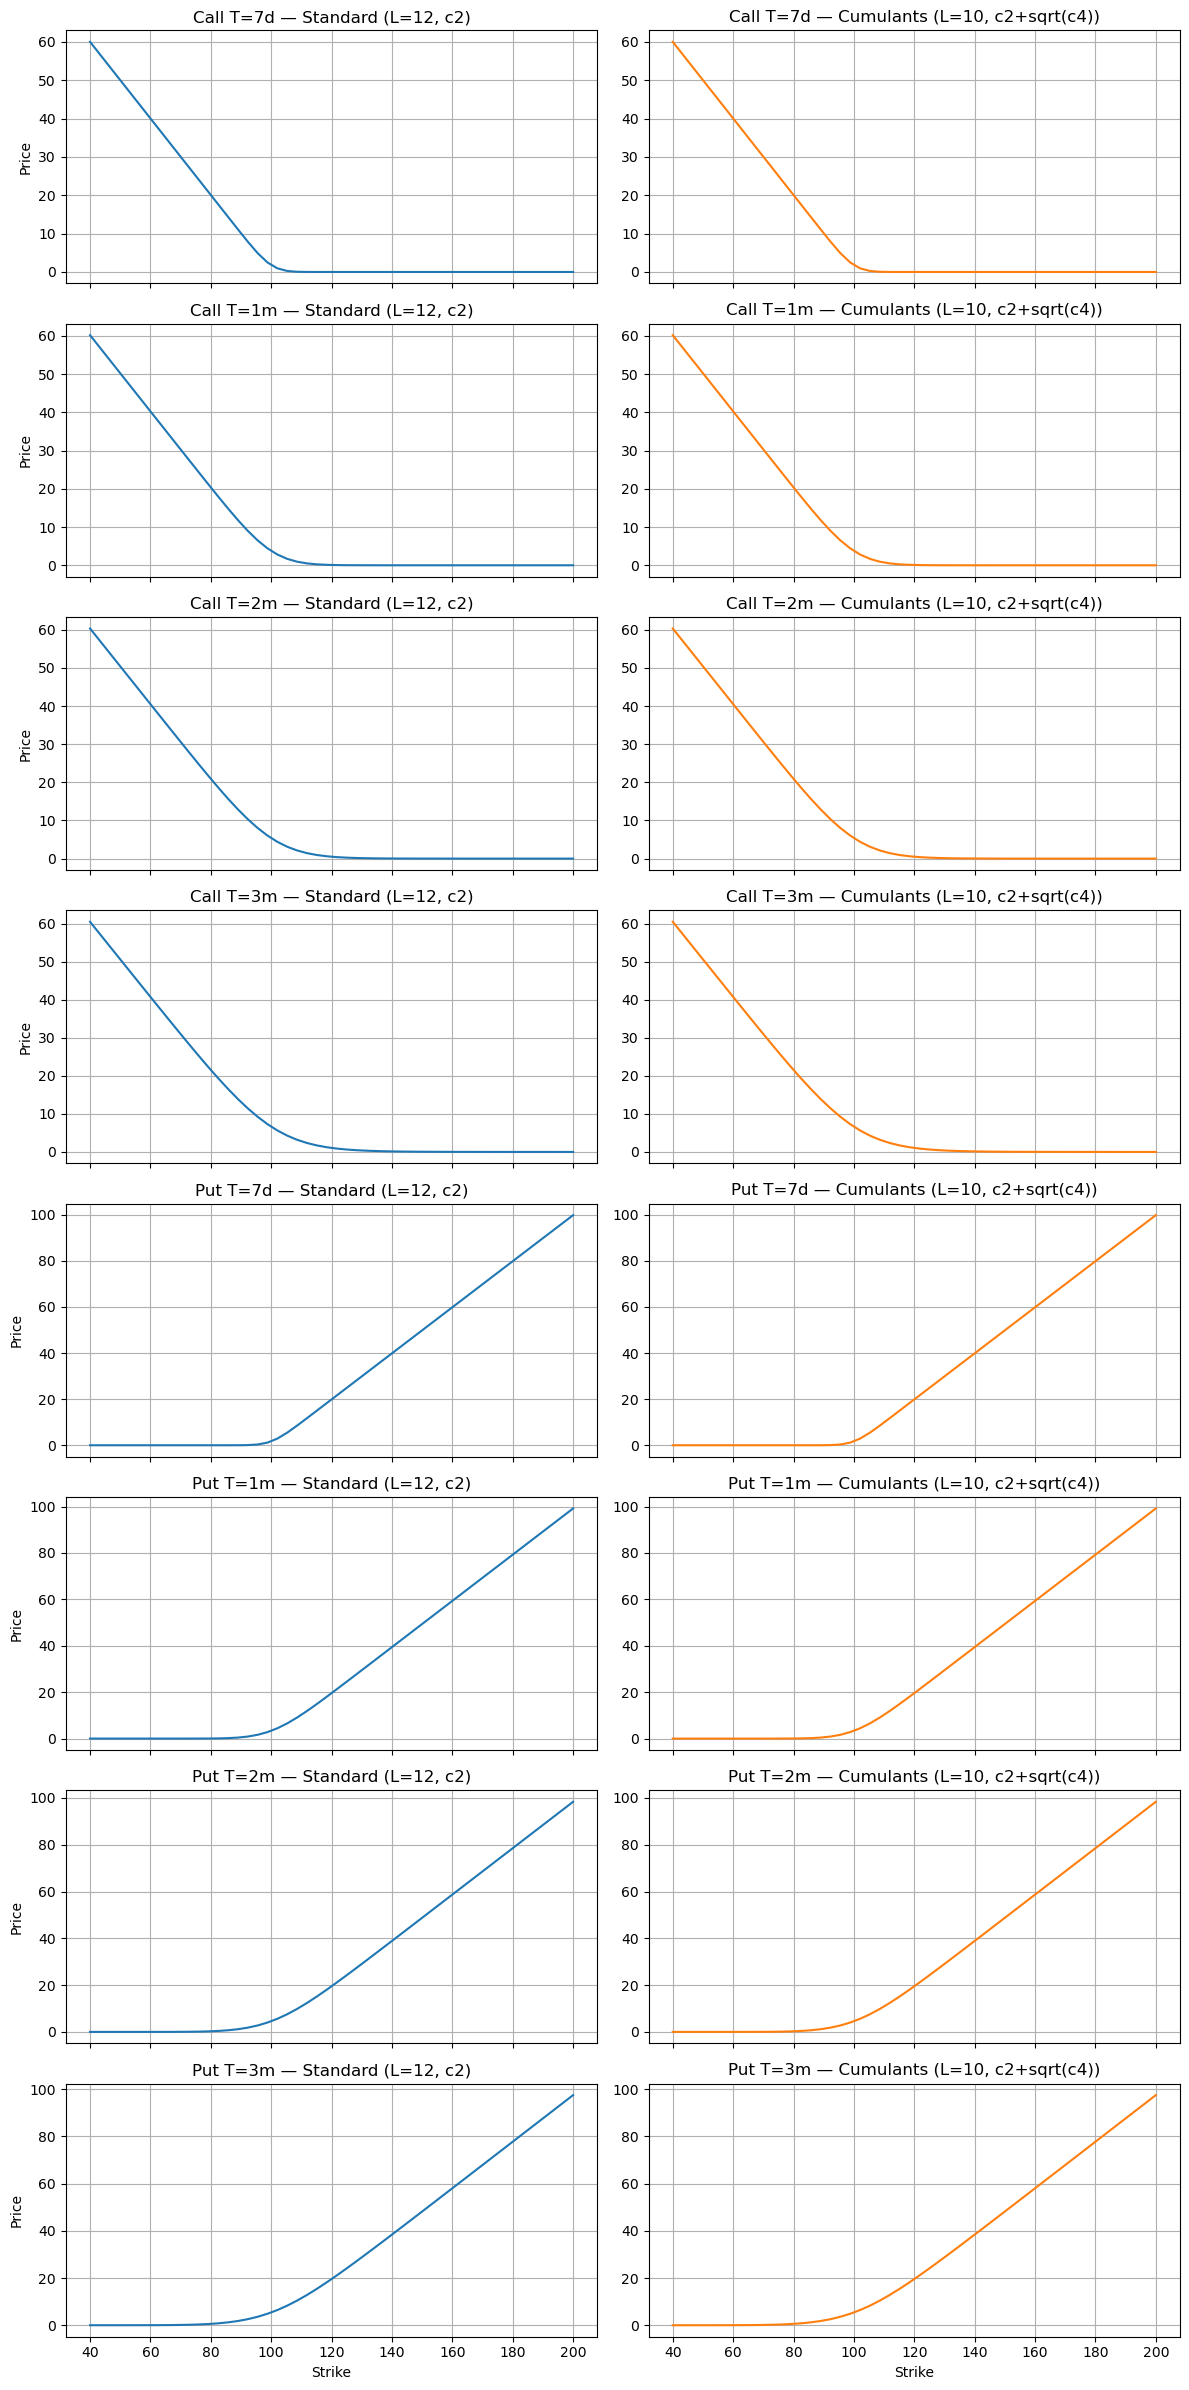

In [16]:
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(12, 24), sharex=True)

# Calls
for i, lab in enumerate(maturity_labels):
    # Standard
    ax = axes[i, 0]
    ax.plot(strikes, call_price_std[i], color="tab:blue")
    ax.set_title(f"Call T={lab} — Standard (L=12, c2)")
    ax.set_ylabel("Price")
    ax.grid(True)

    # Cumulants
    ax = axes[i, 1]
    ax.plot(strikes, call_price_new[i], color="tab:orange")
    ax.set_title(f"Call T={lab} — Cumulants (L=10, c2+sqrt(c4))")
    ax.grid(True)

# Puts
for i, lab in enumerate(maturity_labels):
    r = 4 + i

    # Standard
    ax = axes[r, 0]
    ax.plot(strikes, put_price_std[i], color="tab:blue")
    ax.set_title(f"Put T={lab} — Standard (L=12, c2)")
    ax.set_ylabel("Price")
    ax.grid(True)

    # Cumulants
    ax = axes[r, 1]
    ax.plot(strikes, put_price_new[i], color="tab:orange")
    ax.set_title(f"Put T={lab} — Cumulants (L=10, c2+sqrt(c4))")
    ax.grid(True)

# x-label only on bottom row (cleaner)
for ax in axes[-1, :]:
    ax.set_xlabel("Strike")

plt.tight_layout()
plt.show()

Yes, everything is fine

### Task 2: Model calibration (30 points)


Let's recover the model parameters that were used in the prevoius episode.
We start with the set of prices.
It is convinient to quote option prices in terms of Black IV.
First, let's get the forward prices


$$F(t, T) = S_t e^{r(T-t)}.$$

In [17]:
forward_prices = ms.stock_price * np.exp(ms.interest_rate * (times - ms.time))
forward_prices

array([100.0959364 , 100.4118045 , 100.82530483, 101.24050797])

In practive we also do not know the interest rate and know only the zero-coupon bond prices which are called the *discount factors*

$$DF(t, T) = e^{-r(T-t)}$$

In [18]:
discount_factors = np.exp(-ms.interest_rate * (times - ms.time))
discount_factors

array([0.99904156, 0.99589884, 0.99181451, 0.98774692])

Now let's get the flat vectors of all necessary data and organize it into a DataFrame

In [19]:
# Use the grid that matches the expected plot
strikes_cal = np.linspace(70, 130, 25)  # strike starts at 70
tenors_cal = np.array([0.25, 0.50, 0.75, 1.00])  # in years

calls_cal = CallStockOption(strike_price=strikes_cal[None, :],
                            expiration_time=tenors_cal[:, None])

# Price on this grid
call_price_cal = price(calls_cal, ms, params, n_points=8192)

# Build forwards/DFs on this grid
F = ms.stock_price * np.exp(ms.interest_rate * tenors_cal)  # shape (4,)
DF = np.exp(-ms.interest_rate * tenors_cal)  # shape (4,)

k_br, t_br, f_br, df_br = np.broadcast_arrays(
    calls_cal.strike_price,
    calls_cal.expiration_time - ms.time,
    F[:, None],
    DF[:, None],
)

# Undiscount prices & enforce arbitrage bounds (for IV stability)
undisc = call_price_cal / df_br

eps = 1e-12
intrinsic_undisc = np.maximum(f_br - k_br, 0.0)
upper_undisc = f_br

undisc = np.clip(undisc, intrinsic_undisc + eps, upper_undisc - eps)

# Compute IV
iv = implied_volatility_vec(undisc, f_br, k_br, t_br, "c")

In [20]:
df_market_data = pd.DataFrame(dict(
    forward=f_br.flatten(),
    strike=k_br.flatten(),
    tenor=t_br.flatten(),
    discount_factor=df_br.flatten(),
    iv=iv.flatten()
))
df_market_data.head()

,forward,strike,tenor,discount_factor,iv
0,101.257845,70.0,0.25,0.987578,0.368698
1,101.257845,72.5,0.25,0.987578,0.361995
2,101.257845,75.0,0.25,0.987578,0.355465
3,101.257845,77.5,0.25,0.987578,0.349117
4,101.257845,80.0,0.25,0.987578,0.342968


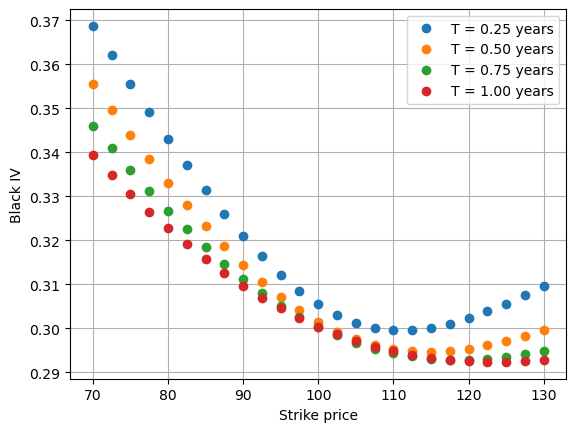

In [21]:
_, ax = plt.subplots()

for tenor in df_market_data.tenor.unique():
    data = df_market_data.query("tenor == @tenor")
    ax.plot(data["strike"], data["iv"], "o", label=f"T = {tenor:.2f} years")

ax.set_xlabel("Strike price")
ax.set_ylabel("Black IV")
ax.legend()
plt.grid(True)
plt.show()

Use the implementation of your COS method (together with truncation range adjustments from the previous tasks) to calibrate the model to the market data  dataframe generated above.

Your calibration objective function is:
$$
\mathrm{Objective} =
\frac1{|\mathrm{tenors}|} \sum\limits_{T \sim \mathrm{tenors}}
\frac1{|\mathrm{strikes}|} \sum\limits_{K \sim \mathrm{strikes}}
\bigl( IV_{\text{data}}(T, K) - IV_{\text{model}}(T, K) \bigr)^2
$$

You should recover the Heston parameters used to generate the data. Plot the original data along with the calibrated IV curve (see [Seminar 7](https://github.com/VegaInstitute/C-StochasticVolatility/blob/main/Seminar%207.ipynb), the last plot).

In [27]:
tenors = np.sort(df_market_data["tenor"].unique())
strikes = np.sort(df_market_data["strike"].unique())

# matrix shape (nT, nK)
iv_data = (
    df_market_data
    .pivot(index="tenor", columns="strike", values="iv")
    .loc[tenors, strikes]
    .to_numpy()
)

In [28]:
def model_iv_surface(params: HestonParams, n_points: int = 2048) -> np.ndarray:
    # create option grid
    calls = CallStockOption(
        strike_price=strikes[None, :],
        expiration_time=tenors[:, None]
    )

    # COS prices
    call_price = price_with_trunc_func(
        calls, ms, params, trunc_func=calc_trunc_range, n_points=n_points
    )

    # forwards and discount factors
    F = ms.stock_price * np.exp(ms.interest_rate * tenors)  # (nT,)
    DF = np.exp(-ms.interest_rate * tenors)  # (nT,)

    k_br, t_br, f_br, df_br = np.broadcast_arrays(
        calls.strike_price,
        calls.expiration_time - ms.time,
        F[:, None],
        DF[:, None],
    )

    undisc = call_price / df_br

    # enforce no-arbitrage bounds for IV inversion stability
    eps = 1e-12
    intrinsic_undisc = np.maximum(f_br - k_br, 0.0)  # (F-K)+
    upper_undisc = f_br  # call <= F (undiscounted)
    undisc = np.clip(undisc, intrinsic_undisc + eps, upper_undisc - eps)

    iv_model = implied_volatility_vec(undisc, f_br, k_br, t_br, "c")
    return iv_model

In [29]:
from scipy.optimize import minimize


def objective(x: np.ndarray, n_points: int = 2048) -> float:
    v0, kappa, theta, sigma, rho = x

    # hard invalid region penalty
    if (v0 <= 0) or (kappa <= 0) or (theta <= 0) or (sigma <= 0) or (abs(rho) >= 1):
        return 1e6

    p = HestonParams(v=float(v0), kappa=float(kappa), theta=float(theta),
                     sigma=float(sigma), rho=float(rho))

    iv_model = model_iv_surface(p, n_points=n_points)
    mse = np.mean((iv_data - iv_model) ** 2)

    # soft Feller penalty (helps optimizer stay in sane region)
    feller_violation = max(0.0, sigma ** 2 - 2.0 * kappa * theta)
    mse += 100.0 * feller_violation ** 2

    return float(mse)


bounds = [
    (1e-3, 0.5),  # v0
    (0.1, 8.0),  # kappa
    (1e-3, 0.5),  # theta
    (0.05, 2.0),  # sigma
    (-0.95, 0.95)  # rho
]

# a few starts (robust)
starts = [
    np.array([0.08, 1.5, 0.08, 0.6, -0.1]),
    np.array([0.12, 2.5, 0.12, 0.8, -0.3]),
    np.array([0.05, 1.0, 0.05, 0.5, 0.0]),
]

best = None
for x0 in starts:
    res = minimize(lambda z: objective(z, n_points=2048),
                   x0=x0, bounds=bounds, method="L-BFGS-B")
    if (best is None) or (res.fun < best.fun):
        best = res

best.x, best.fun, best.success, best.message

(array([ 0.10135569,  4.12503928,  0.09806611,  0.88784481, -0.22639735]),
 5.9312963461304045e-06,
 True,
 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH')

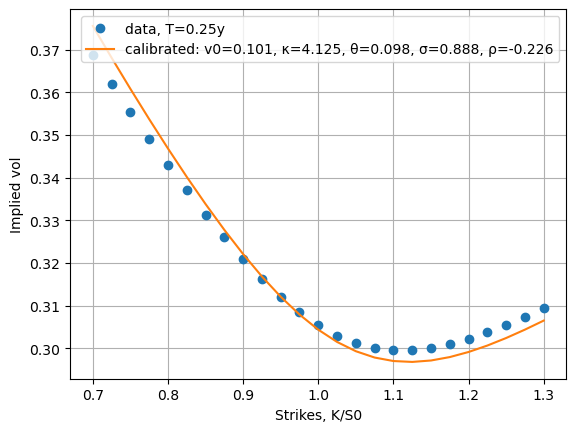

In [30]:
import matplotlib.pyplot as plt

# turn best.x into HestonParams (this is what I called params_cal)
params_cal = HestonParams(
    v=float(best.x[0]),
    kappa=float(best.x[1]),
    theta=float(best.x[2]),
    sigma=float(best.x[3]),
    rho=float(best.x[4]),
)

# compute calibrated IV surface (use higher n_points for a smooth curve)
iv_cal = model_iv_surface(params_cal, n_points=8192)

T_show = 0.25
iT = int(np.where(np.isclose(tenors, T_show))[0][0])

m = strikes / ms.stock_price  # K/S0

fig, ax = plt.subplots()
ax.plot(m, iv_data[iT], "o", label=f"data, T={tenors[iT]:.2f}y")
ax.plot(m, iv_cal[iT], "-", label=(
    f"calibrated: v0={params_cal.v:.3f}, κ={params_cal.kappa:.3f}, "
    f"θ={params_cal.theta:.3f}, σ={params_cal.sigma:.3f}, ρ={params_cal.rho:.3f}"
))
ax.set_xlabel("Strikes, K/S0")
ax.set_ylabel("Implied vol")
ax.grid(True)
ax.legend()
plt.show()

### Task 3: Model calibration with bid-ask spread (20 points)

On illiquid markets there is usually a noticable difference between the best buy and the best sell prices for options.
The difference is called the *bid-ask spread*.
We give you a synthetic data obtained with Heston model with some parameters.
The difference is that now you have two prices (correspondingly, two IVs) for each option: the bid price and the ask price.


You will not get the perfect calibration because of the spreads.
The following objective tries to make the IV in the middle of the bid and ask on average:
$$
\mathrm{Objective} =
\frac1{|\mathrm{tenors}|} \sum\limits_{T \sim \mathrm{tenors}}
\frac1{|\mathrm{strikes}|} \sum\limits_{K \sim \mathrm{strikes}}
\frac12 \sum\limits_{\mathrm{side} \in \{ \text{bid}, \text{ask} \}}
\bigl( IV_{\text{data}}(T, K, \mathrm{side}) - IV_{\text{model}}(T, K) \bigr)^2
$$

Implement this objective and calibrate the model to the synthetic data with spread.

In [35]:
df_market_data = pd.read_csv("data/synth_bid_ask.csv")
df_market_data

,forward,strike,tenor,discount_factor,bid_iv,ask_iv
0,100.752820,70.000000,0.25,0.992528,0.406888,0.446888
1,100.752820,74.285714,0.25,0.992528,0.394230,0.434230
2,100.752820,78.571429,0.25,0.992528,0.381944,0.421944
3,100.752820,82.857143,0.25,0.992528,0.370030,0.410030
4,100.752820,87.142857,0.25,0.992528,0.358515,0.398515
5,100.752820,91.428571,0.25,0.992528,0.347460,0.387460
6,100.752820,95.714286,0.25,0.992528,0.336967,0.376967
7,100.752820,100.000000,0.25,0.992528,0.327183,0.367183
8,100.752820,104.285714,0.25,0.992528,0.318296,0.358296
9,100.752820,108.571429,0.25,0.992528,0.310509,0.350509


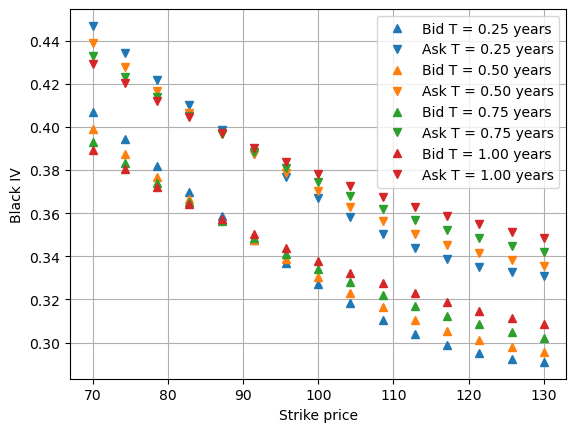

In [36]:
_, ax = plt.subplots()

for i, tenor in enumerate(df_market_data.tenor.unique()):
    data = df_market_data.query("tenor == @tenor")
    ax.plot(data["strike"], data["bid_iv"], "^", label=f"Bid T = {tenor:.2f} years", c=f"C{i}")
    ax.plot(data["strike"], data["ask_iv"], "v", label=f"Ask T = {tenor:.2f} years", c=f"C{i}")

ax.set_xlabel("Strike price")
ax.set_ylabel("Black IV")
ax.legend()
plt.grid(True)
plt.show()

Calibrate the model to the data with bid-ask spread and plot the graph with market data and calibrated model.

In [37]:
tenors = np.sort(df_market_data["tenor"].unique())
strikes = np.sort(df_market_data["strike"].unique())

bid_iv = (
    df_market_data
    .pivot(index="tenor", columns="strike", values="bid_iv")
    .loc[tenors, strikes]
    .to_numpy()
)

ask_iv = (
    df_market_data
    .pivot(index="tenor", columns="strike", values="ask_iv")
    .loc[tenors, strikes]
    .to_numpy()
)

In [38]:
def objective_bid_ask(x: np.ndarray, n_points: int = 2048) -> float:
    v0, kappa, theta, sigma, rho = x

    if (v0 <= 0) or (kappa <= 0) or (theta <= 0) or (sigma <= 0) or (abs(rho) >= 1):
        return 1e6

    p = HestonParams(v=float(v0), kappa=float(kappa), theta=float(theta),
                     sigma=float(sigma), rho=float(rho))

    iv_model = model_iv_surface(p, n_points=n_points)  # shape (nT, nK)
    if not np.all(np.isfinite(iv_model)):
        return 1e6

    # mean over T,K of 0.5*((bid-model)^2 + (ask-model)^2)
    mse = 0.5 * ((bid_iv - iv_model) ** 2 + (ask_iv - iv_model) ** 2)
    loss = float(np.mean(mse))

    # optional: soft Feller penalty
    feller_violation = max(0.0, sigma ** 2 - 2.0 * kappa * theta)
    loss += 100.0 * feller_violation ** 2

    return loss


bounds = [
    (1e-3, 0.5),  # v0
    (0.1, 8.0),  # kappa
    (1e-3, 0.5),  # theta
    (0.05, 2.0),  # sigma
    (-0.95, 0.95)  # rho
]

starts = [
    np.array([0.08, 1.5, 0.08, 0.6, -0.1]),
    np.array([0.12, 2.5, 0.12, 0.8, -0.3]),
    np.array([0.05, 1.0, 0.05, 0.5, 0.0]),
]

best = None
for x0 in starts:
    res = minimize(lambda z: objective_bid_ask(z, n_points=2048),
                   x0=x0, bounds=bounds, method="L-BFGS-B")
    if (best is None) or (res.fun < best.fun):
        best = res

best.x, best.fun, best.success, best.message

(array([ 0.11452835,  2.65514602,  0.15467467,  0.85087331, -0.42353032]),
 0.00041416057115786797,
 True,
 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH')

In [39]:
params_cal = HestonParams(*map(float, best.x))
print(params_cal)

HestonParams(v=0.11452834838011067, kappa=2.6551460183272155, theta=0.15467467429767245, sigma=0.850873307088972, rho=-0.4235303198352942)


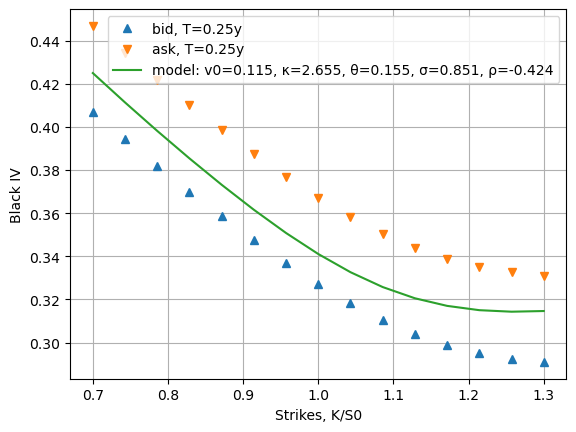

In [40]:
iv_cal = model_iv_surface(params_cal, n_points=8192)

T_show = tenors[0]
iT = int(np.where(np.isclose(tenors, T_show))[0][0])

m = strikes / ms.stock_price  # K/S0

fig, ax = plt.subplots()
ax.plot(m, bid_iv[iT], "^", label=f"bid, T={T_show:.2f}y")
ax.plot(m, ask_iv[iT], "v", label=f"ask, T={T_show:.2f}y")
ax.plot(m, iv_cal[iT], "-", label=(
    f"model: v0={params_cal.v:.3f}, κ={params_cal.kappa:.3f}, "
    f"θ={params_cal.theta:.3f}, σ={params_cal.sigma:.3f}, ρ={params_cal.rho:.3f}"
))

ax.set_xlabel("Strikes, K/S0")
ax.set_ylabel("Black IV")
ax.grid(True)
ax.legend()
plt.show()

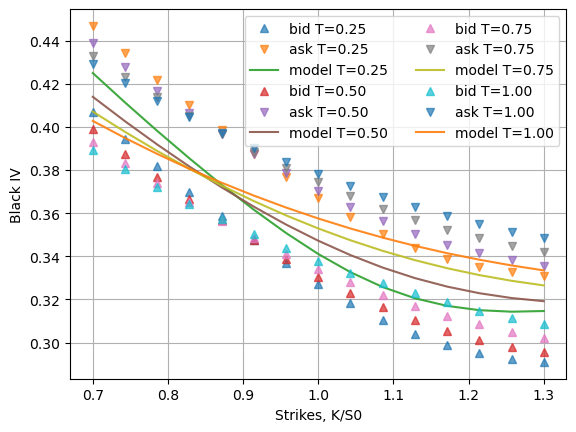

In [41]:
fig, ax = plt.subplots()
for i, T in enumerate(tenors):
    m = strikes / ms.stock_price
    ax.plot(m, bid_iv[i], "^", alpha=0.7, label=f"bid T={T:.2f}")
    ax.plot(m, ask_iv[i], "v", alpha=0.7, label=f"ask T={T:.2f}")
    ax.plot(m, iv_cal[i], "-", alpha=0.9, label=f"model T={T:.2f}")
ax.set_xlabel("Strikes, K/S0")
ax.set_ylabel("Black IV")
ax.grid(True)
ax.legend(ncol=2)
plt.show()

## Episode 2: Capturing the response (40 points)

### Task 4: Calibration to smile and response

Assume that you are a trader on a vanilla derivatives desk and every day you observe on the market the implied volatilities for vanilla options contracts. In order to conduct an appropriate hedging strategy, you need to capture the volatility dynamics observing on the market. For some reason, your choice is the Heston stochastic volatility model.

For the sake of simplicity, you are dealing only with option contracts for one time to expiration $T=1$ year (that is, you observe on the market the implied volatility curve rather than the whole surface) and you have two snapshots of this market for subsequent dates *18/11/2025* and *19/11/2025*.

Hence, given two implied volatility curves, you wish your calibration to meet two requirements:

* The model is calibrated to the implied volatility curve observed at *18/11/2025*.

* The **same** model provides a correct implied volatility response, that is when the spot $S$ changes from $S=150$ to $S=154.5$ on *19/11/2025*, the implied volatilities provided from the model move the same way as it goes on the market.

Provide a model calibartion algorithm which meets the requreiemtns above. The answer should contain a set of calibrated Heston model paramters together with the plots showing that the corresponding model provides an appropriate implied volatility curve and volatility response.

For this task you may use any pricing algorithm (Carr-Madan, COS method, direct integration, etc.) in Heston model you wish.

In [42]:
file_name = "data/response_calibration.csv"
df = pd.read_csv(file_name, index_col=0)
df.head()

,IV_t(K),IV_{t+1}(K),S_t,S_{t+1},K,T,r
0,0.217310,0.229206,150,154.5,127.50,1,0.05
1,0.188706,0.201528,150,154.5,138.75,1,0.05
2,0.158467,0.173783,150,154.5,150.00,1,0.05
3,0.136581,0.146240,150,154.5,161.25,1,0.05
4,0.126814,0.127843,150,154.5,172.50,1,0.05


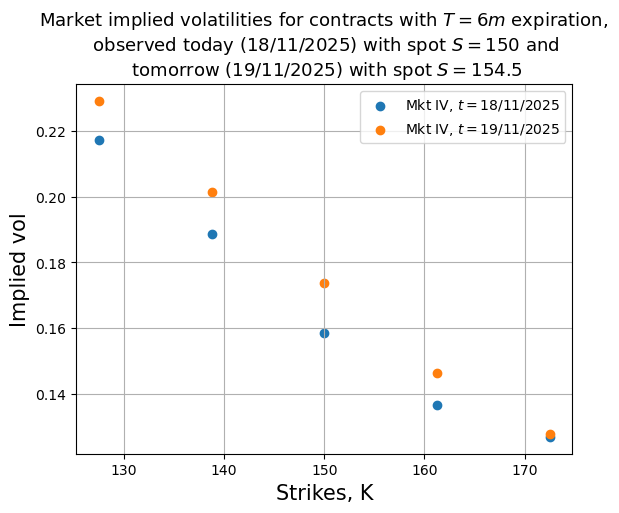

In [43]:
plt.scatter(df["K"], df["IV_t(K)"], label="Mkt IV, $t=$18/11/2025")
plt.scatter(df["K"], df["IV_{t+1}(K)"], label="Mkt IV, $t=$19/11/2025")
plt.title(
    "Market implied volatilities for contracts with $T=6m$ expiration, \n observed today (18/11/2025) with spot $S=${} and \n tomorrow (19/11/2025) with spot $S=${}".format(
        df["S_t"].values[0], df["S_{t+1}"].values[0]), fontsize=13)
plt.ylabel("Implied vol", fontsize=15)
plt.xlabel("Strikes, K", fontsize=15)
plt.legend()
plt.grid(True)
plt.show()

In [44]:
K = df["K"].to_numpy()
T = float(df["T"].iloc[0])
r = float(df["r"].iloc[0])
S_t = float(df["S_t"].iloc[0])
S_tp1 = float(df["S_{t+1}"].iloc[0])

iv_t = df["IV_t(K)"].to_numpy()
iv_tp1 = df["IV_{t+1}(K)"].to_numpy()

In [45]:
def model_iv_curve_for_spot(params: HestonParams, spot: float, n_points: int = 4096) -> np.ndarray:
    ms_local = MarketState(stock_price=spot, interest_rate=r)

    calls = CallStockOption(
        strike_price=K[None, :],
        expiration_time=np.array([[T]])
    )

    call_price = price_with_trunc_func(
        calls, ms_local, params, trunc_func=calc_trunc_range, n_points=n_points
    )

    F = spot * np.exp(r * T)
    DF = np.exp(-r * T)

    k_br, t_br, f_br, df_br = np.broadcast_arrays(
        calls.strike_price,
        calls.expiration_time - ms_local.time,
        F,
        DF,
    )

    undisc = call_price / df_br

    # no-arbitrage bounds for stable IV inversion
    eps = 1e-12
    undisc = np.clip(undisc, np.maximum(f_br - k_br, 0.0) + eps, f_br - eps)

    iv_model = implied_volatility_vec(undisc, f_br, k_br, t_br, "c")
    return iv_model.reshape(-1)

In [46]:
def objective_response(x: np.ndarray, lam_resp: float = 1.0, n_points: int = 2048) -> float:
    v0, kappa, theta, sigma, rho = x

    # reject invalid params
    if (v0 <= 0) or (kappa <= 0) or (theta <= 0) or (sigma <= 0) or (abs(rho) >= 1):
        return 1e6

    p = HestonParams(v=float(v0), kappa=float(kappa), theta=float(theta),
                     sigma=float(sigma), rho=float(rho))

    iv_m_t = model_iv_curve_for_spot(p, S_t, n_points=n_points)
    iv_m_tp1 = model_iv_curve_for_spot(p, S_tp1, n_points=n_points)

    if (not np.all(np.isfinite(iv_m_t))) or (not np.all(np.isfinite(iv_m_tp1))):
        return 1e6

    # Requirement 1: fit today
    mse_fit = np.mean((iv_t - iv_m_t) ** 2)

    # Requirement 2: match response (move the same way)
    d_iv_mkt = iv_tp1 - iv_t
    d_iv_model = iv_m_tp1 - iv_m_t
    mse_resp = np.mean((d_iv_mkt - d_iv_model) ** 2)

    # optional: soft Feller penalty helps keep "reasonable" params
    feller_violation = max(0.0, sigma ** 2 - 2.0 * kappa * theta)

    return float(mse_fit + lam_resp * mse_resp + 100.0 * feller_violation ** 2)

In [47]:
bounds = [
    (1e-3, 0.5),  # v0
    (0.1, 8.0),  # kappa
    (1e-3, 0.5),  # theta
    (0.05, 2.0),  # sigma
    (-0.95, 0.95)  # rho
]

starts = [
    np.array([0.08, 1.5, 0.08, 0.6, -0.3]),
    np.array([0.12, 2.5, 0.12, 0.8, -0.6]),
    np.array([0.05, 1.0, 0.05, 0.5, -0.1]),
]

lam_resp = 1.0  # try 0.3, 1.0, 3.0 if needed

best = None
for x0 in starts:
    res = minimize(lambda z: objective_response(z, lam_resp=lam_resp, n_points=2048),
                   x0=x0, bounds=bounds, method="L-BFGS-B")
    if (best is None) or (res.fun < best.fun):
        best = res

params_cal = HestonParams(*map(float, best.x))
print("best.x =", best.x)
print("objective =", best.fun)
print("success =", best.success, "|", best.message)
print("params_cal =", params_cal)

best.x = [ 1.00000000e-03  3.14856193e+00  4.01317349e-02  5.02693092e-01
 -9.50000000e-01]
objective = 0.00012349420349478288
success = True | CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
params_cal = HestonParams(v=0.001, kappa=3.1485619273848964, theta=0.04013173486316038, sigma=0.5026930919374328, rho=-0.95)


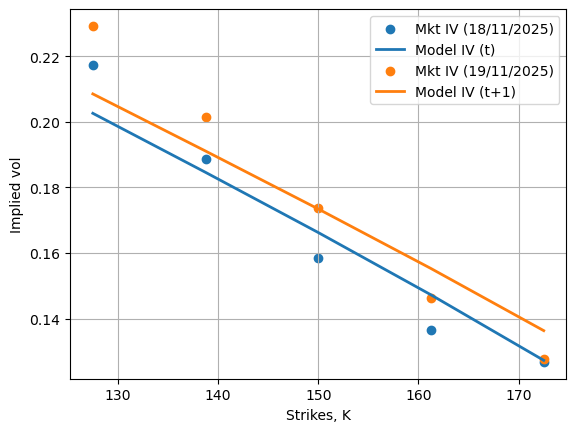

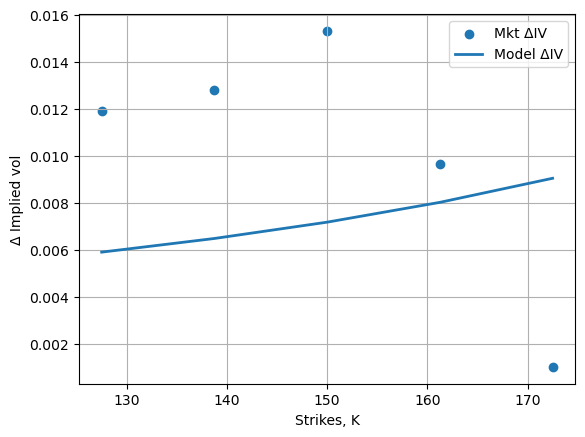

In [48]:
import matplotlib.pyplot as plt

iv_m_t = model_iv_curve_for_spot(params_cal, S_t, n_points=8192)
iv_m_tp1 = model_iv_curve_for_spot(params_cal, S_tp1, n_points=8192)

# Smile plots
fig, ax = plt.subplots()
ax.scatter(K, iv_t, label="Mkt IV (18/11/2025)")
ax.plot(K, iv_m_t, label="Model IV (t)", linewidth=2)
ax.scatter(K, iv_tp1, label="Mkt IV (19/11/2025)")
ax.plot(K, iv_m_tp1, label="Model IV (t+1)", linewidth=2)
ax.set_xlabel("Strikes, K")
ax.set_ylabel("Implied vol")
ax.grid(True)
ax.legend()
plt.show()

# Response plot (delta IV)
fig, ax = plt.subplots()
ax.scatter(K, iv_tp1 - iv_t, label="Mkt ΔIV")
ax.plot(K, iv_m_tp1 - iv_m_t, label="Model ΔIV", linewidth=2)
ax.set_xlabel("Strikes, K")
ax.set_ylabel("Δ Implied vol")
ax.grid(True)
ax.legend()
plt.show()